### What is LZW Compression?

**LZW (Lempel-Ziv-Welch) compression** is a universal lossless data compression algorithm created by Abraham Lempel, Jacob Ziv, and Terry Welch. It is a dictionary-based compression method that works by identifying repeating sequences of data and replacing them with shorter codes. The core principle involves building a dictionary of these frequently occurring sequences (or phrases) encountered in the input data. Instead of storing the actual sequence, the compressor stores an index to its entry in the dictionary.


#### Significance in Multimedia Analytics

LZW compression holds significant importance in multimedia analytics primarily due to its ability to achieve **lossless compression**, which is crucial for maintaining the quality and integrity of multimedia data. In the context of multimedia analytics, where large volumes of images, audio, and video data are processed, stored, and transmitted, LZW's role is multifaceted:

1.  **Reducing File Sizes**: It efficiently reduces the size of multimedia files without any loss of original data, making storage more economical and transmission faster. This is vital for managing vast multimedia datasets in analytics.
2.  **Efficient Transmission**: Smaller file sizes mean less bandwidth is required for transmitting multimedia content, which is critical for real-time analytics, streaming services, and distributed data processing.
3.  **Data Integrity**: As a lossless method, LZW ensures that the decompressed data is an exact replica of the original. This is paramount in applications where data fidelity is critical, such as medical imaging, scientific data, or archival purposes.

#### Applications

One of the most prominent applications of LZW compression is in the **GIF (Graphics Interchange Format)** image format. GIFs, widely used for web graphics and animations, rely on LZW to compress their pixel data. While GIFs are limited to 256 colors, LZW's effectiveness in compressing patterns and repetitive sequences in images made it an ideal choice for this format. Other applications include early forms of TIFF (Tagged Image File Format) and some Unix utilities like `compress`.

#### Benefits

The benefits of using LZW in multimedia contexts are substantial:

*   **Lossless Compression**: Guarantees no loss of data quality, which is essential for multimedia assets where visual or audio fidelity cannot be compromised.
*   **Speed**: LZW is relatively fast for both compression and decompression, making it suitable for applications requiring quick processing of multimedia data.
*   **Widespread Adoption**: Its historical use in popular formats like GIF has established it as a well-understood and implemented standard, ensuring compatibility across various platforms and applications.
*   **Universal Applicability**: While particularly effective for data with repetitive patterns (like images with large areas of uniform color), it can be applied to any type of data.

### LZW Encoding Algorithm Steps

LZW (Lempel-Ziv-Welch) encoding is a lossless data compression algorithm that replaces repeating sequences of characters with fixed-length codes. It builds a dictionary of these sequences on the fly.

1.  **Initialization**:
    *   Initialize the dictionary with all possible single-character codes. For example, if using 8-bit ASCII, the dictionary will contain entries for ASCII values 0-255, where each character maps to its ASCII integer value as its code. The next available code starts from 256.
    *   `current_sequence` is initialized as an empty string.

2.  **Encoding Loop**:
    *   Read the input stream character by character.
    *   For each `character` read:
        *   Form a `new_sequence` by appending the `character` to `current_sequence` (i.e., `new_sequence = current_sequence + character`).
        *   **If `new_sequence` is found in the dictionary**:
            *   Update `current_sequence` to `new_sequence`.
        *   **If `new_sequence` is NOT found in the dictionary**:
            *   Output the code associated with `current_sequence` (the longest sequence found in the dictionary so far).
            *   Add `new_sequence` to the dictionary with the next available code.
            *   Set `current_sequence` to `character`.
    *   Repeat until all input characters are processed.

3.  **Dictionary Updates**:
    *   New entries are added to the dictionary whenever a `new_sequence` (formed by `current_sequence` + `character`) is encountered that is not yet in the dictionary.
    *   The `new_sequence` is assigned the next available, unused code.

4.  **Final Output**:
    *   After the loop finishes, output the code for the final `current_sequence`.

### LZW Decoding Algorithm Steps

LZW decoding reconstructs the original data from the compressed codes by maintaining a dictionary that mirrors the one built during encoding.

1.  **Initialization**:
    *   Initialize the dictionary with all possible single-character codes, identical to the encoder's initialization (e.g., ASCII values 0-255 mapping to their character representations).
    *   `previous_code` is initialized to an invalid value or the first received code.
    *   `current_string` is initialized as an empty string.

2.  **Decoding Loop**:
    *   Read the encoded codes one by one from the input stream.
    *   For each `current_code` read:
        *   **If `current_code` is in the dictionary**:
            *   Retrieve `current_string` corresponding to `current_code` from the dictionary.
        *   **If `current_code` is NOT in the dictionary** (this happens when the encoder just added a new entry based on `previous_string + first_char_of_current_string`):
            *   `current_string` is formed by `previous_string` + `first_character_of_previous_string` (the first character of the string represented by `previous_code`). This is a special case known as the "KLM rule" or "rule of thumb" for LZW.
        *   **Output `current_string`**.

3.  **Dictionary Updates**:
    *   After decoding `current_string`:
        *   If `previous_code` exists (i.e., it's not the very first code processed):
            *   Form a `new_entry` by appending the `first_character_of_current_string` to the string represented by `previous_code`.
            *   Add this `new_entry` to the dictionary with the next available code.
        *   Update `previous_code` to `current_code` for the next iteration.

4.  **Repeat** until all encoded codes are processed.

```markdown
### LZW Encoding Example: 'ABABABA'

Let's choose the input string "ABABABA" to illustrate the LZW encoding process.

**Initial Dictionary:**
We start with a dictionary containing all single-character ASCII codes. For simplicity in this example, we'll only include the characters present in our input string and assign them initial codes. New codes will start from 256.

| Character | Code |
|-----------|------|
| A         | 0    |
| B         | 1    |

**Encoding Process:**

| Iteration | Current Input Character | `current_sequence` | `new_sequence` | In Dictionary? | Output Code | New Dictionary Entry | Updated `current_sequence` |
|-----------|-------------------------|--------------------|----------------|----------------|-------------|----------------------|----------------------------|
| 1         | A                       | A                  | AB             | No             | 0           | AB: 256              | B                          |
| 2         | B                       | B                  | BA             | No             | 1           | BA: 257              | A                          |
| 3         | A                       | A                  | AB             | Yes            |             |                      | AB                         |
| 4         | B                       | AB                 | ABA            | No             | 256         | ABA: 258             | A                          |
| 5         | A                       | A                  | AB             | Yes            |             |                      | AB                         |
| 6         | B                       | AB                 | ABA            | Yes            |             |                      | ABA                        |
| 7         | A                       | ABA                | ABAB           | No             | 258         | ABAB: 259            | B                          |
| 8         | (End of input)          | B                  |                |                | 1           |                      |                            |

**Final Output Sequence:**
`[0, 1, 256, 258, 1]`

**Final Dictionary:**

| Sequence | Code |
|----------|------|
| A        | 0    |
| B        | 1    |
| AB       | 256  |
| BA       | 257  |
| ABA      | 258  |
| ABAB     | 259  |
```

This table clearly shows each step of the LZW encoding for the string "ABABABA", including how the dictionary grows and what codes are output at each stage.

In [1]:
def lzw_encode(uncompressed_data):
    """
    Compress a string using LZW encoding.
    Args:
        uncompressed_data (str): The input string to compress.
    Returns:
        list: A list of integers representing the compressed data.
    """
    # Initialize dictionary with single characters (ASCII 0-255)
    dictionary_size = 256
    dictionary = {chr(i): i for i in range(dictionary_size)}

    current_sequence = ""
    compressed_codes = []

    for char in uncompressed_data:
        new_sequence = current_sequence + char
        if new_sequence in dictionary:
            current_sequence = new_sequence
        else:
            # Output the code for the current sequence
            compressed_codes.append(dictionary[current_sequence])
            # Add the new sequence to the dictionary
            dictionary[new_sequence] = dictionary_size
            dictionary_size += 1
            current_sequence = char

    # Output the last sequence
    if current_sequence:
        compressed_codes.append(dictionary[current_sequence])

    return compressed_codes

def lzw_decode(compressed_codes):
    """
    Decompress a list of LZW-encoded integers back into a string.
    Args:
        compressed_codes (list): A list of integers representing the compressed data.
    Returns:
        str: The decompressed string.
    """
    # Initialize dictionary with single characters (ASCII 0-255)
    dictionary_size = 256
    dictionary = {i: chr(i) for i in range(dictionary_size)}

    if not compressed_codes:
        return ""

    # The first code always corresponds to a single character
    previous_code = compressed_codes[0]
    decompressed_data = dictionary[previous_code]
    previous_char_sequence = decompressed_data

    for code in compressed_codes[1:]:
        if code in dictionary:
            current_sequence = dictionary[code]
        else:
            # This is the 'KLM rule' case: when code is not yet in dictionary
            # It must be the previously seen character sequence plus its first character
            current_sequence = previous_char_sequence + previous_char_sequence[0]

        decompressed_data += current_sequence

        # Add new sequence to dictionary: previous_char_sequence + first char of current_sequence
        dictionary[dictionary_size] = previous_char_sequence + current_sequence[0]
        dictionary_size += 1

        previous_char_sequence = current_sequence

    return decompressed_data

print("LZW encoding and decoding functions defined.")

LZW encoding and decoding functions defined.


Original text length: 94 characters
Original text (first 50 chars): ABABABABABABABABABABABABABABABABABABABABABABABABAB...

Compressed data length: 19 codes
Compressed data (first 20 codes): [65, 66, 256, 258, 257, 260, 259, 262, 261, 264, 263, 266, 265, 268, 267, 270, 269, 272, 259]...

Decompressed text length: 94 characters
Decompressed text (first 50 chars): ABABABABABABABABABABABABABABABABABABABABABABABABAB...

Original and decompressed text match: True


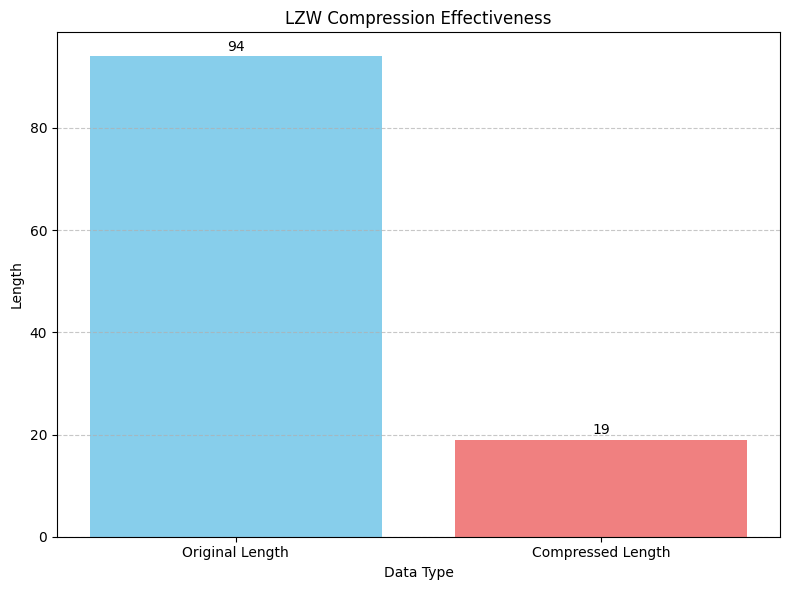

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Choose a suitable input string
original_text = "ABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABABAB"
# A longer string with repetitions to better illustrate compression
# original_text = "WBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBB\n\n# 2. Encode the original text
compressed_data = lzw_encode(original_text)

# 3. Decode the compressed data
decompressed_text = lzw_decode(compressed_data)

# 4. Verify that the decompressed text is identical to the original text
print(f"Original text length: {len(original_text)} characters")
print(f"Original text (first 50 chars): {original_text[:50]}...")
print(f"\nCompressed data length: {len(compressed_data)} codes")
print(f"Compressed data (first 20 codes): {compressed_data[:20]}...")
print(f"\nDecompressed text length: {len(decompressed_text)} characters")
print(f"Decompressed text (first 50 chars): {decompressed_text[:50]}...")

is_match = (original_text == decompressed_text)
print(f"\nOriginal and decompressed text match: {is_match}")

# 5. Calculate the length of the original text and compressed data
original_length = len(original_text)
compressed_length = len(compressed_data)

# 6. Create a bar chart comparing the lengths
labels = ['Original Length', 'Compressed Length']
lengths = [original_length, compressed_length]
x = np.arange(len(labels))

plt.figure(figsize=(8, 6))
plt.bar(x, lengths, color=['skyblue', 'lightcoral'])
plt.xlabel('Data Type')
plt.ylabel('Length')
plt.title('LZW Compression Effectiveness')
plt.xticks(x, labels)

# Add legend (though colors are self-explanatory with labels)
# For clarity, let's add values on top of bars
for i, v in enumerate(lengths):
    plt.text(x[i], v + 0.5, str(v), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()